# Can AI Agents Recover From Failure?

This notebook studies the chain `failure_type -> recovery_strategy ->
recovery_success`, including **repeated recovery attempts on the same
failure**, **failure cascades**, and the latency/token cost of recovering.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA = "../data"
runs = pd.read_csv(f"{DATA}/agent_runs.csv")
agents = pd.read_csv(f"{DATA}/agents.csv")
failures = pd.read_csv(f"{DATA}/failure_events.csv")
recoveries = pd.read_csv(f"{DATA}/recovery_events.csv")

# each row = one recovery ATTEMPT (a failure with 2 attempts contributes 2 rows here)
fr = failures.merge(recoveries, on=["run_id", "failure_id"]).merge(
    runs[["run_id", "agent_id"]], on="run_id"
).merge(agents[["agent_id", "model", "capability_tier"]], on="agent_id")

print(f"Failure events:    {len(failures)}")
print(f"Recovery attempts: {len(recoveries)}  (>= failure count: failures can have >1 attempt)")
print(f"Recovery attempted (of failures): {recoveries.drop_duplicates('failure_id')['recovery_attempted'].mean():.1%}")

Failure events:    3802
Recovery attempts: 4334  (>= failure count: failures can have >1 attempt)
Recovery attempted (of failures): 75.4%


## Recovery success by failure type

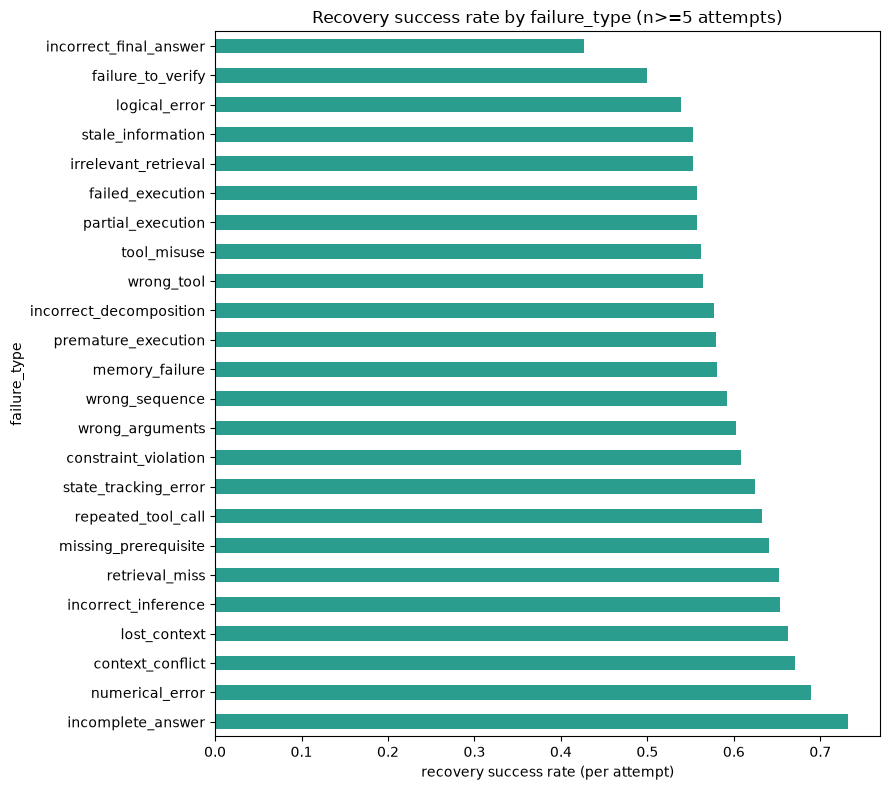

,mean,count
failure_type,,
incomplete_answer,0.732394,71
numerical_error,0.689076,119
context_conflict,0.670588,85
lost_context,0.662963,270
incorrect_inference,0.653846,156
retrieval_miss,0.652632,95
missing_prerequisite,0.641026,78
repeated_tool_call,0.632911,237
state_tracking_error,0.625000,280


In [2]:
attempted = fr[fr["recovery_attempted"]]
by_type = (
    attempted.groupby("failure_type")["recovery_success"]
    .agg(["mean", "count"])
    .query("count >= 5")
    .sort_values("mean", ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 8))
by_type["mean"].plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_title("Recovery success rate by failure_type (n>=5 attempts)")
ax.set_xlabel("recovery success rate (per attempt)")
plt.tight_layout()
plt.show()
by_type

## Recovery success by severity level

Severity is assigned by documented rubric (`docs/taxonomy.md`, level
1=minor .. 4=critical — see `docs/taxonomy.md` "Severity rubric"), not
arbitrarily. Critical (level 4) failures are, by taxonomy construction,
never marked recoverable — this section confirms that shows up in the
actual recovery data, not just as a documented assumption.

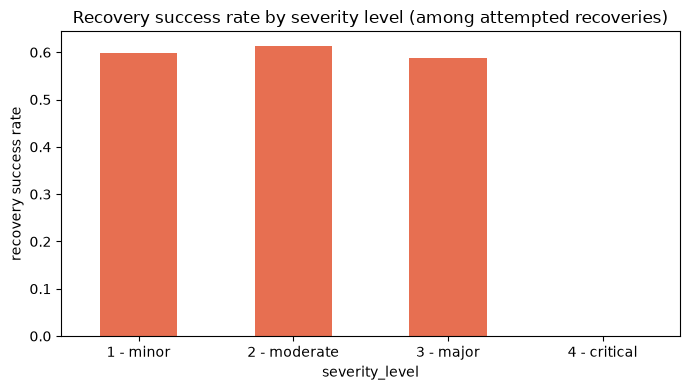

Level-4 (critical) failures with any recovery attempt: 0 (expected: 0, by taxonomy construction)


In [3]:
severity_labels = {1: "1 - minor", 2: "2 - moderate", 3: "3 - major", 4: "4 - critical"}
by_severity = attempted.copy()
by_severity["severity_label"] = by_severity["severity_level"].map(severity_labels)
sev_stats = by_severity.groupby("severity_label")["recovery_success"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(7, 4))
sev_stats["mean"].reindex(severity_labels.values()).plot(kind="bar", ax=ax, color="#e76f51")
ax.set_title("Recovery success rate by severity level (among attempted recoveries)")
ax.set_xlabel("severity_level")
ax.set_ylabel("recovery success rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(f"Level-4 (critical) failures with any recovery attempt: {(fr[fr.severity_level==4]['recovery_attempted']).sum()} (expected: 0, by taxonomy construction)")

## Recovery success by model

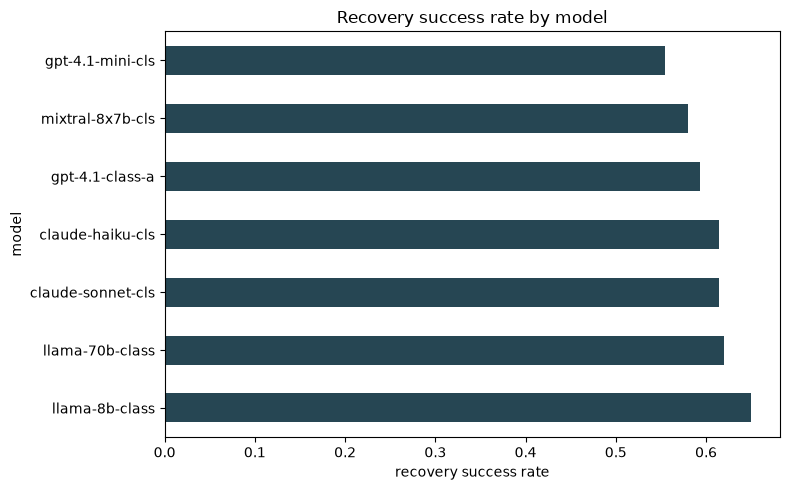

Recovery success rate by agent capability_tier (simulation parameter, not a real-model claim):
capability_tier
high      0.601923
medium    0.616930
low       0.595092
Name: recovery_success, dtype: float64


In [4]:
by_model = attempted.groupby("model")["recovery_success"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
by_model.plot(kind="barh", ax=ax, color="#264653")
ax.set_title("Recovery success rate by model")
ax.set_xlabel("recovery success rate")
plt.tight_layout()
plt.show()

by_tier = attempted.groupby("capability_tier")["recovery_success"].mean().reindex(["high", "medium", "low"])
print("Recovery success rate by agent capability_tier (simulation parameter, not a real-model claim):")
print(by_tier)

## Repeated recovery attempts

When a first recovery attempt fails on a non-critical failure, the agent
may try again with a different strategy. Does trying again actually help?

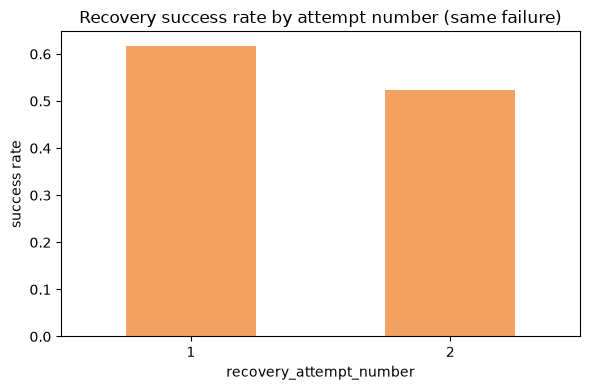

,mean,count
recovery_attempt_number,,
1,0.617237,2866
2,0.524436,532


In [5]:
attempt_stats = attempted.groupby("recovery_attempt_number")["recovery_success"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(6, 4))
attempt_stats["mean"].plot(kind="bar", ax=ax, color="#f4a261")
ax.set_title("Recovery success rate by attempt number (same failure)")
ax.set_xlabel("recovery_attempt_number")
ax.set_ylabel("success rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
attempt_stats

## Recovery cost: latency and tokens

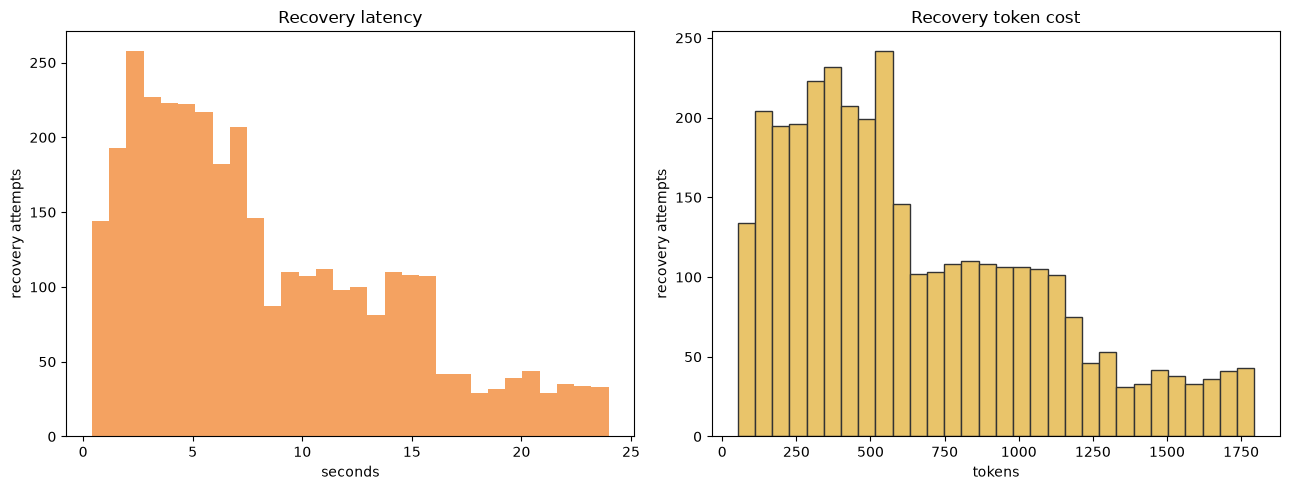

Median recovery latency: 6,811 ms
Median recovery token cost: 542 tokens
Median token cost, successful recoveries:   542
Median token cost, unsuccessful recoveries:  544


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(attempted["recovery_latency_ms"] / 1000, bins=30, color="#f4a261")
axes[0].set_title("Recovery latency")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("recovery attempts")

axes[1].hist(attempted["recovery_token_cost"], bins=30, color="#e9c46a", edgecolor="#333")
axes[1].set_title("Recovery token cost")
axes[1].set_xlabel("tokens")
axes[1].set_ylabel("recovery attempts")
plt.tight_layout()
plt.show()

print(f"Median recovery latency: {attempted['recovery_latency_ms'].median():,.0f} ms")
print(f"Median recovery token cost: {attempted['recovery_token_cost'].median():,.0f} tokens")

succ = attempted[attempted["recovery_success"]]
fail = attempted[~attempted["recovery_success"]]
print(f"Median token cost, successful recoveries:   {succ['recovery_token_cost'].median():,.0f}")
print(f"Median token cost, unsuccessful recoveries:  {fail['recovery_token_cost'].median():,.0f}")

## Most effective strategies overall

In [7]:
strategy_stats = (
    attempted.groupby("recovery_strategy")
    .agg(attempts=("recovery_success", "count"),
         success_rate=("recovery_success", "mean"),
         median_latency_ms=("recovery_latency_ms", "median"),
         median_token_cost=("recovery_token_cost", "median"))
    .sort_values("success_rate", ascending=False)
)
strategy_stats.round(3)

,attempts,success_rate,median_latency_ms,median_token_cost
recovery_strategy,,,,
ask_for_clarification,139,0.676,6480.0,558.0
verify_result,494,0.664,7167.5,549.5
alternative_tool,521,0.631,6960.0,549.0
replan,605,0.603,6528.0,540.0
use_additional_evidence,305,0.600,7110.0,534.0
reformulate_query,114,0.596,6523.0,565.0
change_execution_strategy,391,0.596,6364.0,521.0
rollback,397,0.579,6990.0,531.0
retry,432,0.505,6787.5,560.5


## Failure cascades and recovery

Does a cascading failure (one caused by an earlier failure in the same
run) recover as easily as an independent one?

                  mean  count
is_cascading                 
False         0.475869   3854
True          0.445833    480


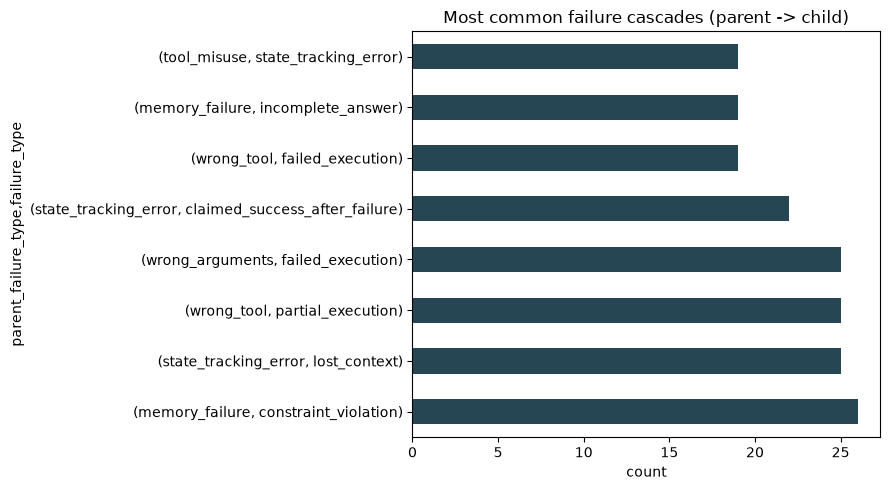

In [8]:
cascade_recovery = fr.groupby("is_cascading")["recovery_success"].agg(["mean", "count"])
print(cascade_recovery)

cascading_ids = failures[failures["is_cascading"]]["failure_id"]
cascade_pairs = failures[failures["is_cascading"]].merge(
    failures[["failure_id", "failure_type"]].rename(columns={"failure_id": "parent_failure_id", "failure_type": "parent_failure_type"}),
    on="parent_failure_id",
)
top_cascades = cascade_pairs.groupby(["parent_failure_type", "failure_type"]).size().sort_values(ascending=False).head(8)
fig, ax = plt.subplots(figsize=(9, 5))
top_cascades.plot(kind="barh", ax=ax, color="#264653")
ax.set_title("Most common failure cascades (parent -> child)")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

## Successful vs. unsuccessful recovery, and unrecoverable failures

Some failure types are marked `recoverable=False` in the taxonomy itself
(e.g. `tool_loop`, `false_verification`, `unsupported_conclusion`,
`unauthorized_action`, `hallucinated_result`,
`claimed_success_after_failure`) — these are architecturally treated as
not-recoverable-in-place, because the agent's own signal about task state
is untrustworthy in exactly these cases (see `docs/taxonomy.md`,
"Severity rubric", level 4). We confirm that shows up correctly below.

In [9]:
never_recovered = failures[~failures["recoverable"]]
print(f"Failures flagged non-recoverable by taxonomy: {len(never_recovered)}")
print(never_recovered["failure_type"].value_counts())

recovered_anyway = fr[(~fr["recoverable"]) & (fr["recovery_success"] == True)]  # noqa: E712
print(f"\nOf those, recovery succeeded anyway in: {len(recovered_anyway)} cases (expected: 0, by construction)")

succ_n = int(attempted["recovery_success"].sum())
unsucc_n = int((~attempted["recovery_success"]).sum())
print(f"\nSuccessful recovery attempts:   {succ_n}")
print(f"Unsuccessful recovery attempts: {unsucc_n}")

Failures flagged non-recoverable by taxonomy: 454
failure_type
tool_loop                        209
unauthorized_action               80
claimed_success_after_failure     71
unsupported_conclusion            46
hallucinated_result               29
false_verification                19
Name: count, dtype: int64

Of those, recovery succeeded anyway in: 0 cases (expected: 0, by construction)

Successful recovery attempts:   2048
Unsuccessful recovery attempts: 1350


### Research questions for future work

1. Does recovery strategy *selection* (not just success rate) correlate
   with agent capability tier — do higher-tier simulated agents pick
   better-fitting strategies for a given failure category?
2. Is there a token/latency budget past which continued recovery attempts
   become net-negative versus simply failing fast and re-planning from
   scratch? The repeated-attempt analysis above is a first step; a full
   cost-benefit model would weigh cumulative cost against the marginal
   success-rate gain from trying again.
3. Within `tool_use` failures — the largest category — which specific
   sub-types (`wrong_tool` vs `wrong_arguments` vs `tool_loop`) respond
   best to `alternative_tool` versus `retry`?
4. Do cascading failures require different recovery strategies than
   independent ones, given they inherit context from an already-troubled
   trajectory?
5. Can recovery success itself be predicted from features available at
   the moment of failure detection (see `02_predict_agent_failure.ipynb`
   for the equivalent question about the original task)?